# Data Size Impact Study
**Course**: CS 3402

This study investigates how the size of training data influences the performance of Classical ML models versus Artificial Neural Networks (ANNs).

### Data Download Instructions
Please download the following datasets from Kaggle and place the CSV files in the same directory as this notebook (or in a subfolder named `data/`).

1. **Credit Card Approval**: [Rikdifos Dataset](https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction)
   * Need: `application_record.csv` and `credit_record.csv`.
2. **Student Placement**: [Sehaj Dataset](https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026)
   * Need: `student_placement_prediction_dataset_2026.csv`.
3. **Digital Distraction**: [Neurocipher Dataset](https://www.kaggle.com/datasets/neurocipher/digital-distraction-vs-academic-performance)
   * Need: CSV file (e.g., `student_digital_life.csv` or similar).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Preprocessing

In [8]:
LIMIT_RECORDS = 5000

def find_path(filename):
    if os.path.exists(filename): return filename
    alt = os.path.join('data', filename)
    if os.path.exists(alt): return alt
    return None

def find_by_keywords(keywords):
    for folder in ['.', 'data']:
        if not os.path.exists(folder): continue
        for f in os.listdir(folder):
            if all(kw.lower() in f.lower() for kw in keywords) and f.endswith('.csv'):
                return os.path.join(folder, f)
    return None

def identify_target(df, keywords, default):
    """Finds a column name containing any of the keywords."""
    for col in df.columns:
        if any(kw.lower() in col.lower() for kw in keywords):
            return col
    return default

datasets = {}
print("Searching for datasets...")

# 1. Credit Card (Classification)
app_path = find_path('application_record.csv')
credit_path = find_path('credit_record.csv')
if app_path and credit_path:
    print("Found Credit Card dataset.")
    app_df = pd.read_csv(app_path, nrows=LIMIT_RECORDS)
    credit_df = pd.read_csv(credit_path)
    credit_df['target'] = credit_df['STATUS'].apply(lambda x: 1 if x in ['1', '2', '3', '4', '5'] else 0)
    target_agg = credit_df.groupby('ID')['target'].max().reset_index()
    datasets['Credit Card'] = {'df': pd.merge(app_df, target_agg, on='ID', how='inner'), 
                             'task': 'classification', 'target': 'target'}
else:
    print("MISSING: Credit Card dataset")

# 2. Student Placement (Classification)
student_file = find_by_keywords(['placement'])
if student_file:
    print(f"Found Student Placement dataset: {student_file}")
    df = pd.read_csv(student_file, nrows=LIMIT_RECORDS)
    target = 'placement_status'

    #encode data for model
    df[target] = df[target].map({
    'Not Placed': 0,
    'Placed': 1
    })

    datasets['Student Placement'] = {
        'df': df,
        'task': 'classification',
        'target': target
    }

    print(f"  Using target column: {target}")

else:
    print("MISSING: Student Placement dataset")

# 3. Digital Distraction (Regression)
dist_file = find_by_keywords(['digital'])
if dist_file:
    print(f"Found Digital Distraction dataset: {dist_file}")
    df = pd.read_csv(dist_file, nrows=LIMIT_RECORDS)
    target = identify_target(df, ['score', 'final', 'exam', 'performance'], 'final_exam_score')
    print(f"  Using target column: {target}")
    datasets['Digital Distraction'] = {'df': df, 'task': 'regression', 'target': target}
else:
    print("MISSING: Digital Distraction dataset")

Searching for datasets...
Found Credit Card dataset.
Found Student Placement dataset: .\student_placement_prediction_dataset_2026.csv
  Using target column: placement_status
Found Digital Distraction dataset: .\student_digital_life.csv
  Using target column: final_exam_score


## 2. Exploratory Data Analysis (EDA)

In [9]:
for name, data in datasets.items():
    print(f"\n-- EDA for {name} --")
    display(data['df'].head(3))
    print(f"Loaded Samples: {len(data['df'])}")


-- EDA for Credit Card --


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0


Loaded Samples: 4478

-- EDA for Student Placement --


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,0,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,0,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,1,11.99


Loaded Samples: 5000

-- EDA for Digital Distraction --


,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14


Loaded Samples: 5000


## 3. Pipeline Setup

In [10]:
def create_pipeline(X, model):
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    return Pipeline([('pre', preprocessor), ('m', model)])

## 4. Experiment Loop

In [16]:
results = []
fractions = [0.1, 0.3, 0.5, 1.0]
seeds = [42, 123, 999]

for name, info in datasets.items():
    print(f"\nRunning Experiment: {name}...")

    df = info['df'].copy().dropna()
    target = info['target']

    if target not in df.columns:
        print(f"  ERROR: Target '{target}' not found in {name}. Available columns: {list(df.columns)}")
        continue

    # --- Split features / target ---
    X = df.drop(columns=[target, 'ID', 'salary_package_lpa', 'student_id'], errors='ignore').copy()
    y = df[target].copy()

    # --- CLEAN FEATURE MATRIX ---
    for col in X.columns:
        if X[col].dtype == 'object':
            try:
                X[col] = pd.to_numeric(X[col])
            except:
                pass  # keep as categorical

    # --- TRAIN / TEST SPLIT ---
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # --- MODELS (disable early stopping for stability) ---
    if info['task'] == 'classification':
        models = {
            'Logistic Regression': LogisticRegression(max_iter=500),
            'MLP (ANN)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, early_stopping=False)
        }
    else:
        models = {
            'Ridge': Ridge(),
            'MLP (ANN)': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, early_stopping=False)
        }

    for m_name, model in models.items():
        print(f"  Training {m_name}...")

        for frac in fractions:
            scores = []

            for seed in seeds:
                # --- SUBSAMPLE TRAINING DATA ---
                if frac < 1.0:
                    if info['task'] == 'classification':
                        X_sub, _, y_sub, _ = train_test_split(
                            X_train_full,
                            y_train_full,
                            train_size = frac,
                            random_state=seed,
                            stratify=y_train_full
                    )
                    else:
                        X_sub, _, y_sub, _ = train_test_split(
                            X_train_full,
                            y_train_full,
                            train_size=frac,
                            random_state=seed
                        )
                else:
                    X_sub, y_sub = X_train_full, y_train_full

                # --- PIPELINE ---
                pipe = create_pipeline(X, model)

                # --- FIT / PREDICT ---
                try:
                    pipe.fit(X_sub, y_sub)
                    preds = pipe.predict(X_test)
                except Exception as e:
                    print(f"    Skipping due to error: {e}")
                    continue

                # --- METRICS ---
                if info['task'] == 'classification':
                    scores.append(accuracy_score(y_test, preds))
                else:
                    scores.append(np.sqrt(mean_squared_error(y_test, preds)))

            # --- STORE RESULTS ---
            if len(scores) > 0:
                results.append({
                    'Dataset': name,
                    'Model': m_name,
                    'Fraction': frac,
                    'Samples': len(X_sub),
                    'Mean': np.mean(scores),
                    'Std': np.std(scores),
                    'Task': info['task']
                })

results_df = pd.DataFrame(results)


Running Experiment: Credit Card...
  Training Logistic Regression...
  Training MLP (ANN)...

Running Experiment: Student Placement...
  Training Logistic Regression...
  Training MLP (ANN)...

Running Experiment: Digital Distraction...
  Training Ridge...
  Training MLP (ANN)...


## 5. Visualization

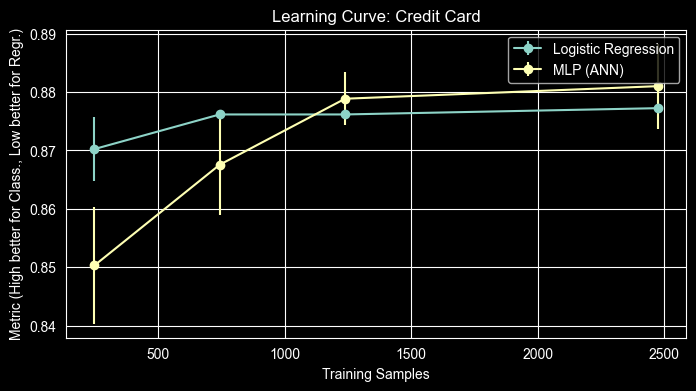

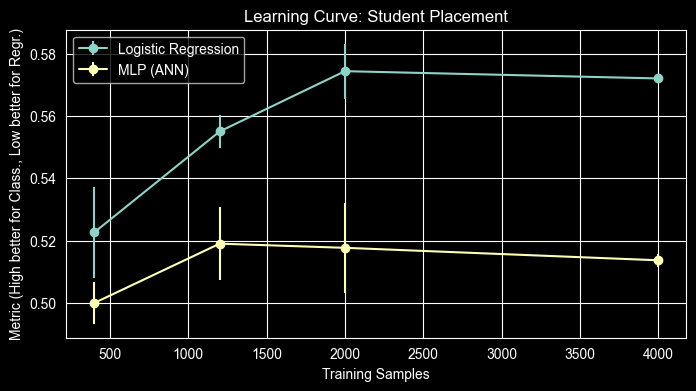

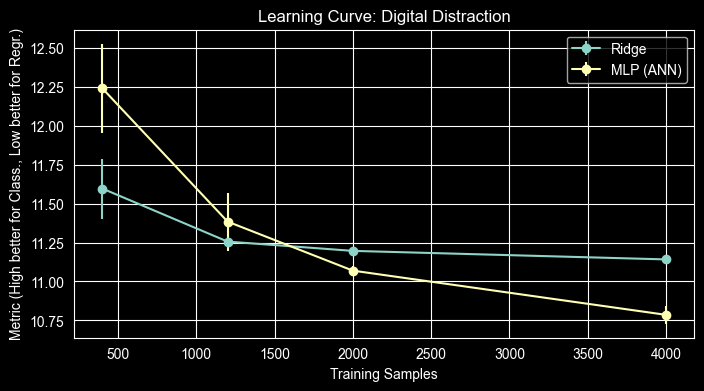

In [17]:
if not results_df.empty:
    for name in results_df['Dataset'].unique():
        sub = results_df[results_df['Dataset'] == name]
        plt.figure(figsize=(8, 4))
        for m in sub['Model'].unique():
            m_sub = sub[sub['Model'] == m]
            plt.errorbar(m_sub['Samples'], m_sub['Mean'], yerr=m_sub['Std'], label=m, marker='o')
        plt.title(f"Learning Curve: {name}")
        plt.xlabel("Training Samples"); plt.ylabel("Metric (High better for Class., Low better for Regr.)")
        plt.legend(); plt.grid(True); plt.show()